# Exploration et Préparation des Données

**Objectif de ce notebook :** Analyser les données historiques de demandes de prêts, comprendre les facteurs qui influencent le défaut de paiement, et préparer un jeu de données "propre" et mathématiquement exploitable pour nos futurs algorithmes de Machine Learning.

In [2]:
#!pip install pandas numpy matplotlib seaborn

## Analyse de la variable cible

Nombre de clients (lignes) : 307511
Nombre de variables (colonnes) : 122



,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


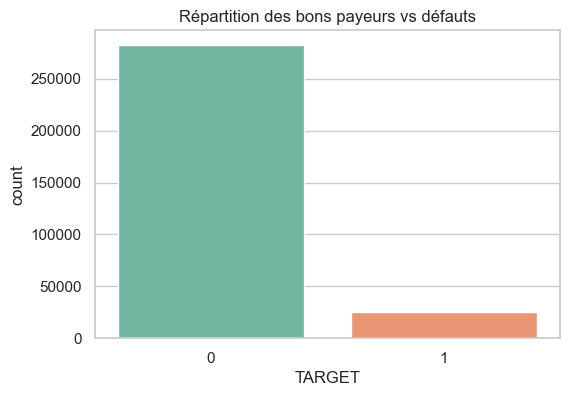

In [ ]:
#librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

#Chargement des données
chemin_fichier = '../data/dataset/application_train.csv'
df = pd.read_csv(chemin_fichier)

#Apercu
print(f"Nombre de clients (lignes) : {df.shape[0]}")
print(f"Nombre de variables (colonnes) : {df.shape[1]}\n")

#Affichage des 5 premières lignes
display(df.head())

#Analyse de la variable cible
repartition = df['TARGET'].value_counts(normalize=True) * 100
print(repartition)

#graphique
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='TARGET', hue='TARGET', palette='Set2', legend=False)
plt.title('Répartition des bons payeurs vs défauts')
plt.show()


La variable `TARGET` indique si le client a remboursé son prêt (0) ou s'il a fait défaut (1). 

Le jeu de données est fortement déséquilibré (environ 92% de bons payeurs pour 8% de défauts). Cela signifie que pour l'évaluation de notre futur modèle, la précision globale sera trompeuse.

## Traitement des Valeurs Manquantes


In [4]:

#Identifier les valeurs manquantes
valeurs_manquantes = df.isnull().sum()
pourcentage_manquant = (valeurs_manquantes / len(df)) * 100
top_manquants = pourcentage_manquant.sort_values(ascending=False).head(20)
print("\nTop 20 des colonnes avec le plus de valeurs manquantes (%) :\n", top_manquants)


Top 20 des colonnes avec le plus de valeurs manquantes (%) :
 COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64


In [5]:
#Suppression des colonnes trop vides
seuil = 60 #arbitraire

colonnes_a_supprimer = pourcentage_manquant[pourcentage_manquant > seuil].index
df = df.drop(columns=colonnes_a_supprimer)

print(f"Nombre de colonnes supprimées : {len(colonnes_a_supprimer)}")
print(f"Nouvelle taille du dataset : {df.shape[1]}")

Nombre de colonnes supprimées : 17
Nouvelle taille du dataset : 105


Les données bancaires contiennent souvent des "trous" (informations non renseignées par le client ou le conseiller). 

Les colonnes possédant plus de 60% de valeurs manquantes (souvent liées aux caractéristiques du bâtiment du client) sont supprimées. Essayer d'imputer une si grande quantité de données introduirait trop de biais (bruit) dans notre modèle.

Pour les colonnes conservées, nous devons combler les valeurs manquantes pour que les algorithmes puissent fonctionner :
* **Variables Numériques :** Nous utilisons la **médiane** plutôt que la moyenne. La médiane est beaucoup moins sensible aux valeurs aberrantes (outliers), ce qui est indispensable en finance où les revenus ou les montants de crédit peuvent être extrêmement élevés pour une minorité de clients.
* **Variables Catégorielles :** Les valeurs non renseignées sont regroupées sous une nouvelle catégorie `"Inconnu"`.

In [6]:
#Trie des colonnes numériques et catégorielles
df_num = df.select_dtypes(include=["float64","int64"])
df_cat = df.select_dtypes(include=["object"])
print(f"Toutes les colonnes ont été trier ? : {df_num.shape[1]+df_cat.shape[1] == df.shape[1]}")

#Remplacer NaN dans les colonnes numériques
df_num = df_num.fillna(df_num.median())

#Remplacer NaN dans les colonnes catégorielles
df_cat = df_cat.fillna("Inconnu")

#Réunir df
df = pd.concat([df_num, df_cat], axis=1)
print(f"Valeurs NaN : {df.isnull().sum().sum()}")


Toutes les colonnes ont été trier ? : True


C:\Users\ameti\AppData\Local\Temp\ipykernel_23848\2786498469.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = df.select_dtypes(include=["object"])


Valeurs NaN : 0


## Feature Engineering

Les algorithmes de Machine Learning ne comprennent que les mathématiques. Nous devons traduire nos variables textuelles (ex: Statut familial, Type de revenu) en variables binaires (0 ou 1) via un **One-Hot Encoding**.

*Note technique :* L'argument `drop_first=True` est utilisé pour supprimer la première modalité de chaque catégorie. Cela évite le problème de la **colinéarité parfaite** (le "piège des variables muettes"), garantissant que la matrice de nos variables restera mathématiquement inversible lors de l'entraînement du modèle.

In [7]:
#Feature Engineering
df = pd.get_dummies(df, drop_first=True)

print(f"Nouvelle taille du dataset après encodage : {df.shape}")

Nouvelle taille du dataset après encodage : (307511, 216)


In [ ]:
# Sauvegarde du dataset
chemin_sauvegarde = '../data/dataset/application_train_cleaned.csv'
df.to_csv(chemin_sauvegarde, index=False)

print("Dataset sauvegardé")

Dataset sauvegardé
